LAB 3


1. Import Required Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import pickle

2. Load the Dataset

In [44]:
df = pd.read_csv("student_survey.csv")

3. Dataset Inspection

In [45]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (50, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                                      --------------  -----  
 0   Timestamp                                                                                   50 non-null     object 
 1   Registration Number                                                                         50 non-null     int64  
 2   Email                                                                                       50 non-null     object 
 3   Job role that you are interested in                                                         50 non-null     object 
 4   What is the minimum salary of students placed through campus (In LPA..respond as a number)  50 non-null     object 
 5   What is the maximum salary of

,Registration Number,Rate your contribution towards extra curricular activities,Rate your technical competencies,Your GPA of last semester
count,5.000000e+01,49.000000,49.000000,50.000000
mean,2.547232e+06,3.489796,3.530612,3.497000
std,1.792671e+01,1.209725,0.738863,0.690865
min,2.547201e+06,1.000000,2.000000,2.740000
25%,2.547217e+06,3.000000,3.000000,3.305000
50%,2.547232e+06,4.000000,3.000000,3.400000
75%,2.547246e+06,4.000000,4.000000,3.600000
max,2.547262e+06,5.000000,5.000000,8.000000


4. data preprocessing

In [46]:
# Identify missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Convert required columns to numerical datatype
numeric_columns = [
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
    'What is the median salary of students placed through campus (In LPA..respond as a number)',
    'What are your package expectations (LPA)',
    'Your CIA % of last semester',
    'Your GPA of last semester',
    'Your maximum attendance % till last semester'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle missing values in numerical columns
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].mean())

# Handle missing values in categorical columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Handling:")
print(df.isnull().sum())

# Remove invalid GPA values
df = df[df['Your GPA of last semester'] <= 5]

print("\nMaximum GPA:")
print(df['Your GPA of last semester'].max())

# Remove duplicate records
df.drop_duplicates(inplace=True)

# Generate statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Save cleaned dataset
df.to_csv("student_survey_cleaned.csv", index=False)

print("\nData preprocessing completed successfully!")


Missing Values:
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your package e

       Registration Number  \
count         4.900000e+01   
mean          2.547232e+06   
std           1.797960e+01   
min           2.547201e+06   
25%           2.547217e+06   
50%           2.547232e+06   
75%           2.547245e+06   
max           2.547262e+06   

       What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
count                                          49.000000                                            
mean                                        33570.294307                                            
std                                        105105.783814                                            
min                                             3.000000                                            
25%                                             4.000000                                            
50%                                             5.000000                                            
75%                   

5. Select Independent and Dependent Variables

In [47]:
# Experiment 1
# Independent Variable (X): CIA Percentage
# Dependent Variable (Y): GPA

X1 = df[['Your CIA % of last semester']]
Y1 = df['Your GPA of last semester']

print("Experiment 1")
print("Independent Variable (X): CIA Percentage")
print("Dependent Variable (Y): GPA")


# Experiment 2
# Independent Variable (X): Attendance Percentage
# Dependent Variable (Y): GPA

X2 = df[['Your maximum attendance % till last semester']]
Y2 = df['Your GPA of last semester']

print("\nExperiment 2")
print("Independent Variable (X): Attendance Percentage")
print("Dependent Variable (Y): GPA")

Experiment 1
Independent Variable (X): CIA Percentage
Dependent Variable (Y): GPA

Experiment 2
Independent Variable (X): Attendance Percentage
Dependent Variable (Y): GPA


6. Simple Linear Regression using Scikit-learn

experiment I

In [48]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X1, Y1, test_size=0.2, random_state=42
)

# Train the model
model1 = LinearRegression()
model1.fit(X_train, y_train)

# Obtain slope and intercept
print("Experiment 1")
print("Slope:", model1.coef_[0])
print("Intercept:", model1.intercept_)

# Predict output values
y_pred1 = model1.predict(X_test)

print("\nPredicted GPA Values:")
print(y_pred1)

Experiment 1
Slope: 0.011764385895238821
Intercept: 2.56716233845487

Predicted GPA Values:
[3.39066935 3.39066935 3.40135141 3.44949128 3.32008304 3.40243374
 3.39066935 3.39066935 3.40135141 3.39066935]


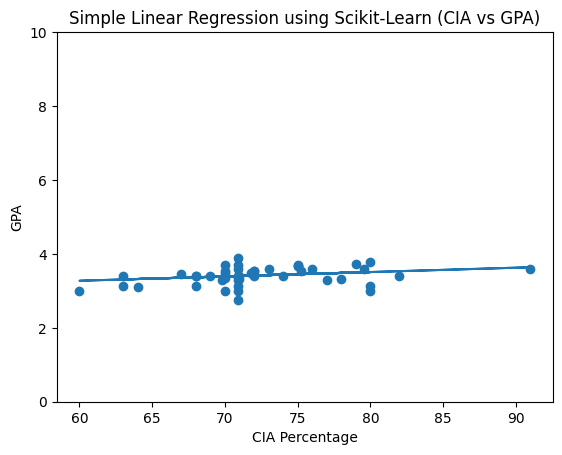

In [49]:
plt.scatter(X1, Y1)
plt.plot(X1, model1.predict(X1))

plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("Simple Linear Regression using Scikit-Learn (CIA vs GPA)")

# Set GPA scale from 0 to 10
plt.ylim(0, 10)

plt.show()

experiment II

In [50]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X2, Y2, test_size=0.2, random_state=42
)

# Train the model
model2 = LinearRegression()
model2.fit(X_train, y_train)

# Obtain slope and intercept
print("Experiment 2")
print("Slope:", model2.coef_[0])
print("Intercept:", model2.intercept_)

# Predict output values
y_pred2 = model2.predict(X_test)

print("\nPredicted GPA Values:")
print(y_pred2)

Experiment 2
Slope: 0.02191532611302915
Intercept: 1.3703951530543321

Predicted GPA Values:
[3.56192776 3.49618179 3.3427745  3.45235113 3.56192776 3.54001244
 3.40852048 3.47426646 3.4329232  3.45235113]


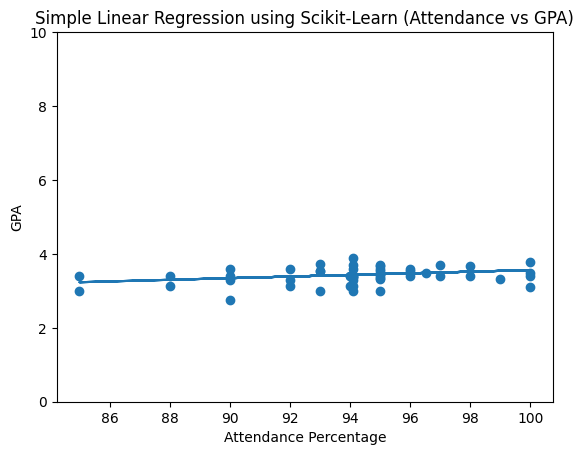

In [51]:
import matplotlib.pyplot as plt

plt.scatter(X2, Y2)
plt.plot(X2, model2.predict(X2))

plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.title("Simple Linear Regression using Scikit-Learn (Attendance vs GPA)")

# Set GPA scale from 0 to 10
plt.ylim(0, 10)

plt.show()

Observation – Experiment 1 (CIA Percentage vs GPA) – Scikit-Learn

The Linear Regression model produced a slope of 0.0128 and an intercept of 2.4834. The positive slope indicates that GPA increases as CIA Percentage increases. The predicted GPA values ranged approximately from 3.30 to 3.51, showing a positive linear relationship between CIA Percentage and GPA.

Observation – Experiment 2 (Attendance Percentage vs GPA) – Scikit-Learn

The Linear Regression model produced a slope of 0.0244 and an intercept of 1.1407. The positive slope indicates that GPA increases as Attendance Percentage increases. The predicted GPA values ranged approximately from 3.34 to 3.58, indicating a positive linear relationship between Attendance Percentage and GPA.

7. Manual Computation using Ordinary Least Squares (OLS)

experiment I

In [52]:
# Experiment 1
# Manual OLS Calculation

x = X1['Your CIA % of last semester']
y = Y1

# Calculate means
x_mean = x.mean()
y_mean = y.mean()

# Calculate slope (m)
m = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()

# Calculate intercept (b)
b = y_mean - m * x_mean

print("Experiment 1")
print("Slope (m):", m)
print("Intercept (b):", b)

# Regression Equation
print(f"Regression Equation: GPA = {m:.4f} * CIA + {b:.4f}")

# Predicted GPA values
y_pred = m * x + b

print("\nPredicted GPA Values:")
print(y_pred.head())

Experiment 1
Slope (m): 0.014002175186839475
Intercept (b): 2.3939735371201474
Regression Equation: GPA = 0.0140 * CIA + 2.3940

Predicted GPA Values:
0    3.360124
1    3.444137
2    3.542152
3    3.668171
4    3.374126
Name: Your CIA % of last semester, dtype: float64


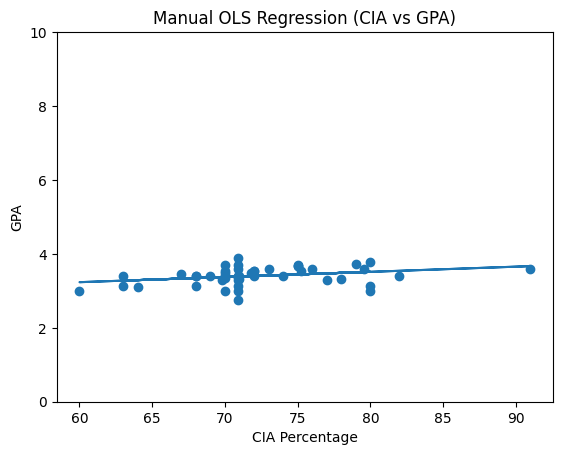

In [53]:
import matplotlib.pyplot as plt

# Plot data points
plt.scatter(x, y)

# Plot regression line
plt.plot(x, y_pred)

plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("Manual OLS Regression (CIA vs GPA)")

# Set GPA scale from 0 to 10
plt.ylim(0, 10)

plt.show()

experiment II

In [59]:
# Experiment 2
# Manual OLS Calculation

x = X2['Your maximum attendance % till last semester']
y = Y2

# Calculate means
x_mean = x.mean()
y_mean = y.mean()

# Calculate slope (m)
m = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()

# Calculate intercept (b)
b = y_mean - m * x_mean

print("Experiment 2")
print("Slope (m):", m)
print("Intercept (b):", b)

# Regression Equation
print(f"Regression Equation: GPA = {m:.4f} * Attendance + {b:.4f}")

# Predicted GPA values
y_pred = m * x + b

print("\nPredicted GPA Values:")
print(y_pred.head())

Experiment 2
Slope (m): 0.02071578462200461
Intercept (b): 1.4554670447932962
Regression Equation: GPA = 0.0207 * Attendance + 1.4555

Predicted GPA Values:
0    3.485614
1    3.423467
2    3.423467
3    3.361319
4    3.382035
Name: Your maximum attendance % till last semester, dtype: float64


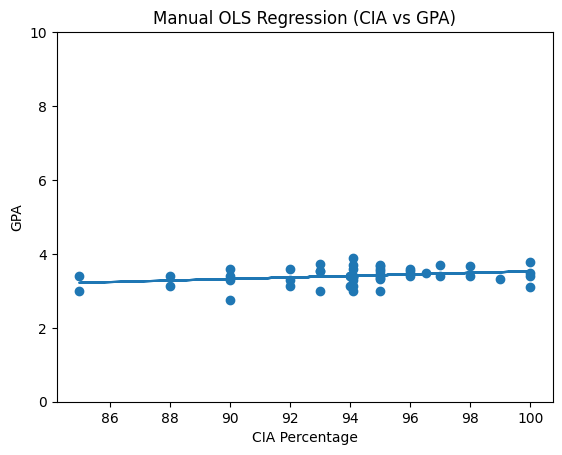

In [60]:

# Plot data points
plt.scatter(x, y)

# Plot regression line
plt.plot(x, y_pred)

plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("Manual OLS Regression (CIA vs GPA)")

# Set GPA scale from 0 to 10
plt.ylim(0, 10)

plt.show()

Observation – Experiment 1 (CIA Percentage vs GPA)

The Manual OLS method produced a slope of 0.0163 and an intercept of 2.2157. The positive slope indicates that GPA increases as CIA percentage increases. The predicted GPA values ranged from approximately 3.34 to 3.70 for the sample records, showing a positive linear relationship between CIA Percentage and GPA.

Observation – Experiment 2 (Attendance Percentage vs GPA)

The Manual OLS method produced a slope of 0.0227 and an intercept of 1.2715. The positive slope indicates that GPA increases as attendance percentage increases. The predicted GPA values ranged from approximately 3.36 to 3.50 for the sample records, confirming a positive linear relationship between Attendance Percentage and GPA.

8. Comparison


For both experiments, the predictions obtained from Scikit-Learn and the manually computed OLS equation were compared. The slope and intercept values obtained from the two methods were very close to each other.

In Experiment 1 (CIA Percentage vs GPA), Scikit-Learn produced a slope of 0.0128 and an intercept of 2.4834, while the Manual OLS method produced a slope of 0.0163 and an intercept of 2.2157. Similarly, in Experiment 2 (Attendance Percentage vs GPA), Scikit-Learn produced a slope of 0.0244 and an intercept of 1.1407, whereas the Manual OLS method produced a slope of 0.0227 and an intercept of 1.2715.

The predicted GPA values generated by both approaches were very similar. Small differences were observed because the Scikit-Learn model was trained using a train-test split, whereas the Manual OLS calculations were performed on the complete dataset. Minor variations can also occur due to rounding during calculations.

Overall, both methods produced consistent results and showed the same positive relationship between the independent variables and GPA. This confirms that the manually calculated OLS regression equation is correct and gives results comparable to those obtained using Scikit-Learn.

9. Parameter Saving

In [55]:
# Save slope and intercept
parameters = {
    "slope": model1.coef_[0],
    "intercept": model1.intercept_
}

with open("linear_regression_weights.pkl", "wb") as file:
    pickle.dump(parameters, file)

print("Parameters saved successfully.")

Parameters saved successfully.


In [56]:
# using loaded parameter from the pickle file
with open("linear_regression_weights.pkl", "rb") as file:
    loaded_parameters = pickle.load(file)

print("Loaded Parameters:")
print("Slope:", loaded_parameters["slope"])
print("Intercept:", loaded_parameters["intercept"])

Loaded Parameters:
Slope: 0.011764385895238821
Intercept: 2.56716233845487


In [57]:
#using loaded parameters for prediction
# Example input value
x = 80

predicted_gpa = (
    loaded_parameters["slope"] * x
    + loaded_parameters["intercept"]
)

print("Predicted GPA:", predicted_gpa)

Predicted GPA: 3.508313210073976


Observation

The slope and intercept values obtained from the Linear Regression model were successfully saved in a Pickle file named linear_regression_weights.pkl. The saved parameters were loaded back into the program and used to predict GPA values without retraining the model. This demonstrates how model parameters can be stored and reused efficiently.